# Project future SLAM poses into RELLIS-3D images (STEPP Step 1)

ROS-free port of STEPP's `extract_future_poses.py` for RELLIS-3D, sequence **00000**.

For every image it:
1. converts the KITTI-format `poses.txt` (world ← LiDAR) into **camera-frame** world poses using the `transforms.yaml` extrinsic (direction is verified automatically),
2. takes the next `FUTURE_STEPS` poses, drops them to the ground plane and widens them to the robot footprint,
3. projects the resulting path ribbon into the image with the Basler intrinsics,
4. writes `pixels.json` (image name → list of `[u, v]` path pixels, full 1920×1200 coords), a camera-frame TUM `poses_cam_tum.txt`, and debug overlay images.

**Requirements:** `numpy`, `opencv-python`, `scipy`, `pyyaml`, `matplotlib` (optional: `tqdm`).

Notes on this data export (verified against the actual files):
- `camera_info.txt` contains only `fx fy cx cy` — no distortion coefficients, so `D = 0` is used.
- `calib.txt` is all identity matrices and is ignored.
- `poses.txt` has exactly one line per image (index-matched).

In [49]:
import json
from pathlib import Path

import cv2
import numpy as np
import yaml
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **k: x

# ----------------------------- CONFIG -----------------------------
DATA_ROOT = Path(r"s:\\#UNIVERSITY\\Capstone\\Code\\Rellis_Stepp\\Rellis_3D")
SEQ = "00004"

SEQ_DIR         = DATA_ROOT / SEQ
IMG_DIR         = SEQ_DIR / "pylon_camera_node"
POSES_TXT       = SEQ_DIR / "poses.txt"
TRANSFORMS_YAML = SEQ_DIR / "transforms.yaml"
CAMERA_INFO     = SEQ_DIR / "camera_info.txt"

OUT_DIR     = Path(r"s:\\#UNIVERSITY\\Capstone\\Code\\Rellis_Stepp\\outputs") / SEQ
OVERLAY_DIR = OUT_DIR / "overlays"

IMG_W, IMG_H = 1920, 1200

FUTURE_STEPS    = 50      # poses projected ahead of each frame (paper: 40, repo: 50)
MIN_MOVE_M      = 0.10    # stationary filter: drop frame if robot moved < this since last kept frame (0 = keep all)
GROUND_OFFSET_M = 1.00    # sensor height above ground on the Warthog -- TUNE VISUALLY below
ROBOT_WIDTH_M   = 1.0     # width of the projected path ribbon -- TUNE VISUALLY below
MIN_Z           = 0.5     # minimum depth (m) in front of the camera for a point to be projectable
PIXEL_STRIDE    = 8       # subsampling stride of path-mask pixels stored in pixels.json
OVERLAY_EVERY   = 25      # save a debug overlay every N kept frames (0 = none)
TEST_FRAME      = 100     # kept-frame index used in the single-frame tuning cell

assert IMG_DIR.is_dir() and POSES_TXT.is_file(), "check DATA_ROOT / SEQ paths"

## 1. Load images + poses (sanity: 1 pose line per image)

In [50]:
img_paths = sorted(IMG_DIR.glob("*.jpg"))
pose_lines = [l for l in POSES_TXT.read_text().splitlines() if l.strip() and not l.startswith("#")]
print(f"{len(img_paths)} images, {len(pose_lines)} pose lines")
assert len(img_paths) == len(pose_lines), "image/pose count mismatch -- match by frame index from the filename instead"

def kitti_line_to_T(line):
    vals = np.array(line.split(), dtype=np.float64)
    assert vals.size == 12, f"expected 12 floats, got {vals.size}"
    T = np.eye(4)
    T[:3, :4] = vals.reshape(3, 4)
    return T

T_wl_all = np.stack([kitti_line_to_T(l) for l in pose_lines])  # T_world<-lidar, one per image

def fname_to_stamp(p):
    # frame000104-1581624652_750.jpg -> 1581624652.750
    return float(p.stem.split("-")[1].replace("_", "."))

stamps_all = np.array([fname_to_stamp(p) for p in img_paths])

dists = np.linalg.norm(np.diff(T_wl_all[:, :3, 3], axis=0), axis=1)
print(f"trajectory length: {dists.sum():.1f} m, median step: {np.median(dists)*100:.1f} cm")
print("first pose t:", np.round(T_wl_all[0][:3, 3], 3))

2059 images, 2059 pose lines
trajectory length: 226.1 m, median step: 12.2 cm
first pose t: [-0.137 -0.401  0.166]


## 2. Camera intrinsics (from `camera_info.txt`: `fx fy cx cy`, no distortion)

In [51]:
fx, fy, cx, cy = np.loadtxt(CAMERA_INFO).ravel()[:4]
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float64)
D = np.zeros(5)  # this export ships no distortion coefficients
print(K)

[[2.81364327e+03 0.00000000e+00 9.69285772e+02]
 [0.00000000e+00 2.80832608e+03 6.24049972e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


## 3. Camera↔LiDAR extrinsic — direction resolved automatically

`transforms.yaml` gives one quaternion + translation but not which way it maps.
Both hypotheses are composed with the LiDAR poses; the one that puts the *future*
robot positions **in front of the camera** (positive optical-axis z while driving
forward) is the correct one.

In [52]:
tf = yaml.safe_load(TRANSFORMS_YAML.read_text())
key = next(k for k in tf if "os1" in k and "pylon" in k)
q, t = tf[key]["q"], tf[key]["t"]
print(f"yaml key: {key}")

T_yaml = np.eye(4)
T_yaml[:3, :3] = Rotation.from_quat([q["x"], q["y"], q["z"], q["w"]]).as_matrix()  # scipy expects (x,y,z,w)
T_yaml[:3, 3] = [t["x"], t["y"], t["z"]]

T_wc_A = T_wl_all @ np.linalg.inv(T_yaml)  # hypothesis A: T_yaml = T_cam<-lidar
T_wc_B = T_wl_all @ T_yaml                 # hypothesis B: T_yaml = T_lidar<-cam

def frac_in_front(T_wc, horizon=30, n_samples=60):
    """Mean fraction of future camera positions with z > 0 in the current camera frame."""
    idxs = np.linspace(0, len(T_wc) - horizon - 2, n_samples).astype(int)
    fracs = []
    for i in idxs:
        T_cw = np.linalg.inv(T_wc[i])
        fut = T_wc[i + 1:i + 1 + horizon, :3, 3]
        moved = np.linalg.norm(fut - T_wc[i, :3, 3], axis=1) > 0.3
        if not moved.any():
            continue
        pc = fut[moved] @ T_cw[:3, :3].T + T_cw[:3, 3]
        fracs.append(float((pc[:, 2] > 0).mean()))
    return float(np.mean(fracs))

fA, fB = frac_in_front(T_wc_A), frac_in_front(T_wc_B)
print(f"fraction of future positions in front of camera:  A (inv(T_yaml)) = {fA:.3f}   B (T_yaml as-is) = {fB:.3f}")

if fA >= fB:
    T_wc_all, EXTRINSIC_CHOICE = T_wc_A, "T_world_cam = T_world_lidar @ inv(T_yaml)"
else:
    T_wc_all, EXTRINSIC_CHOICE = T_wc_B, "T_world_cam = T_world_lidar @ T_yaml"
print("using:", EXTRINSIC_CHOICE)
assert max(fA, fB) > 0.8, "neither direction looks right -- inspect transforms.yaml manually"

yaml key: os1_cloud_node-pylon_camera_node
fraction of future positions in front of camera:  A (inv(T_yaml)) = 0.485   B (T_yaml as-is) = 1.000
using: T_world_cam = T_world_lidar @ T_yaml


## 4. Export camera-frame poses in TUM format (`timestamp x y z qx qy qz qw`)

One line per image, same order as the sorted filenames — directly usable by STEPP's own scripts later.

In [53]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
tum_path = OUT_DIR / "poses_cam_tum.txt"
with open(tum_path, "w") as f:
    for ts, T in zip(stamps_all, T_wc_all):
        x, y, z = T[:3, 3]
        qx, qy, qz, qw = Rotation.from_matrix(T[:3, :3]).as_quat()  # (x,y,z,w) = STEPP's expected order
        f.write(f"{ts:.3f} {x:.6f} {y:.6f} {z:.6f} {qx:.8f} {qy:.8f} {qz:.8f} {qw:.8f}\n")
print("wrote", tum_path)

wrote s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00004\poses_cam_tum.txt


## 5. Stationary filter (keeps images and poses in lockstep)

In [54]:
keep = [0]
for i in range(1, len(T_wc_all)):
    if np.linalg.norm(T_wc_all[i, :3, 3] - T_wc_all[keep[-1], :3, 3]) >= MIN_MOVE_M:
        keep.append(i)
keep = np.array(keep)

imgs   = [img_paths[i] for i in keep]
stamps = stamps_all[keep]
T_wc   = T_wc_all[keep]
T_wl   = T_wl_all[keep]
print(f"kept {len(keep)}/{len(img_paths)} frames after {MIN_MOVE_M} m stationary filter")

kept 1743/2059 frames after 0.1 m stationary filter


## 6. Projection: future ground-path ribbon → image pixels

For each future pose the robot position (LiDAR origin) is dropped `GROUND_OFFSET_M`
straight down in the world frame and widened `±ROBOT_WIDTH_M/2` perpendicular to the
robot's horizontal heading (Ouster x-axis). Consecutive left/right edge points form
quads that are filled into a full-resolution path mask.

In [55]:
def future_ground_strip(idx):
    """World-frame center/left/right ground points of the future path seen from kept frame idx."""
    C, L, R = [], [], []
    for j in range(idx + 1, min(idx + 1 + FUTURE_STEPS, len(T_wl))):
        pos = T_wl[j][:3, 3]
        fwd = T_wl[j][:3, 0].copy()      # Ouster x-axis = robot forward
        fwd[2] = 0.0
        n = np.linalg.norm(fwd)
        if n < 1e-6:
            continue
        fwd /= n
        left = np.array([-fwd[1], fwd[0], 0.0])
        g = pos - np.array([0.0, 0.0, GROUND_OFFSET_M])
        C.append(g)
        L.append(g + 0.5 * ROBOT_WIDTH_M * left)
        R.append(g - 0.5 * ROBOT_WIDTH_M * left)
    return np.array(C), np.array(L), np.array(R)

def world_to_pixels(pts_w, T_wc_i):
    """Project Nx3 world points into the image. Returns Nx2 pixel coords (NaN if behind) and validity mask."""
    if len(pts_w) == 0:
        return np.zeros((0, 2)), np.zeros(0, bool)
    T_cw = np.linalg.inv(T_wc_i)
    pc = pts_w @ T_cw[:3, :3].T + T_cw[:3, 3]
    valid = pc[:, 2] > MIN_Z
    uv = np.full((len(pts_w), 2), np.nan)
    if valid.any():
        proj, _ = cv2.projectPoints(pc[valid].reshape(-1, 1, 3), np.zeros(3), np.zeros(3), K, D)
        uv[valid] = proj.reshape(-1, 2)
    return uv, valid

def path_mask(idx):
    """Full-res binary mask of the future path ribbon + projected centerline points for kept frame idx."""
    mask = np.zeros((IMG_H, IMG_W), np.uint8)
    C, L, R = future_ground_strip(idx)
    if len(C) < 2:
        return mask, np.zeros((0, 2))
    uvL, vL = world_to_pixels(L, T_wc[idx])
    uvR, vR = world_to_pixels(R, T_wc[idx])
    uvC, vC = world_to_pixels(C, T_wc[idx])
    for j in range(len(C) - 1):
        if not (vL[j] and vR[j] and vL[j + 1] and vR[j + 1]):
            continue
        quad = np.array([uvL[j], uvL[j + 1], uvR[j + 1], uvR[j]])
        quad = np.clip(quad, -3e4, 3e4).astype(np.int32)
        if quad[:, 0].max() < 0 or quad[:, 0].min() >= IMG_W or quad[:, 1].max() < 0 or quad[:, 1].min() >= IMG_H:
            continue
        cv2.fillPoly(mask, [quad], 1)
    return mask, uvC[vC]

def make_overlay(idx, mask, centers):
    img = cv2.imread(str(imgs[idx]))
    assert img is not None, f"cv2.imread failed: {imgs[idx]}"
    over = img.copy()
    sel = mask > 0
    over[sel] = (0.45 * over[sel] + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
    inb = centers[np.all((centers >= 0) & (centers < [IMG_W, IMG_H]), axis=1)].astype(np.int32)
    if len(inb) >= 2:
        cv2.polylines(over, [inb], False, (0, 0, 255), 4)
    return over

## 7. Single-frame tuning check — **run this before the full loop**

The green ribbon should hug the ground along the track the robot actually drives.
- Ribbon floats *above* the ground / toward the horizon → **increase** `GROUND_OFFSET_M`.
- Ribbon sinks *below* the ground / too close to the camera → **decrease** it.
- Ribbon too narrow/wide vs. the Warthog's wheel tracks → adjust `ROBOT_WIDTH_M`.

Re-run the CONFIG cell + this cell until it looks right, then run the rest.

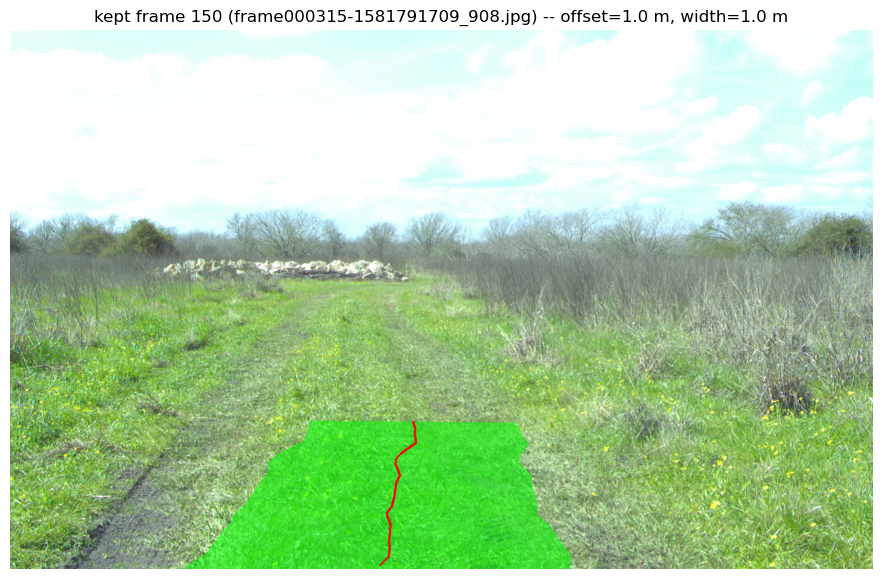

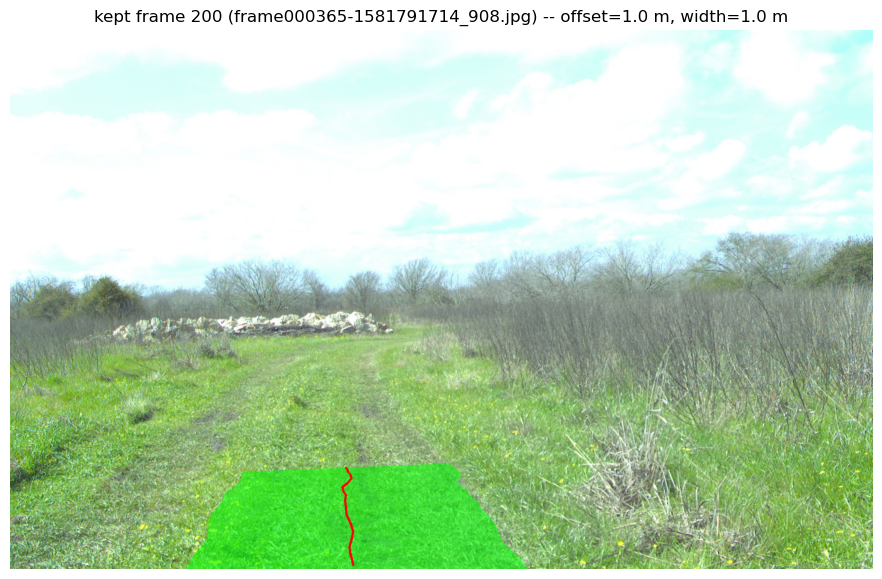

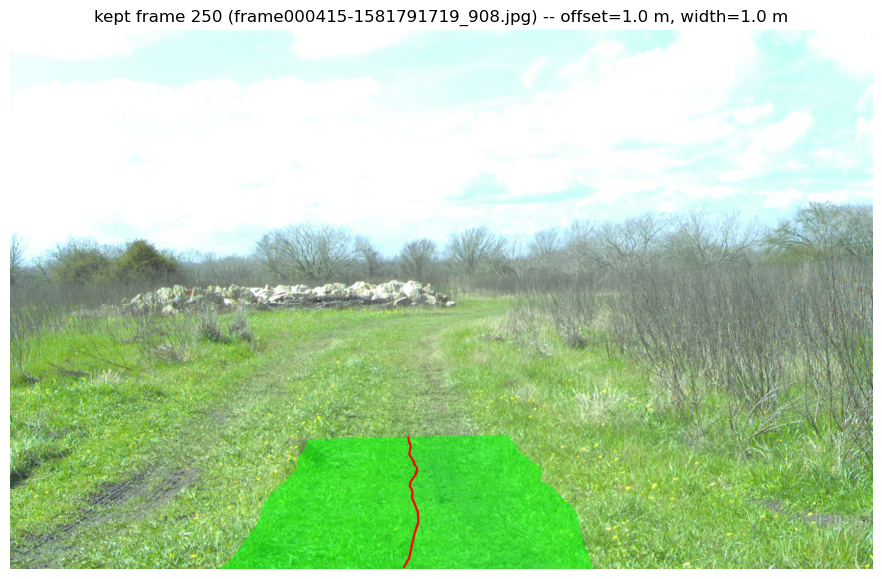

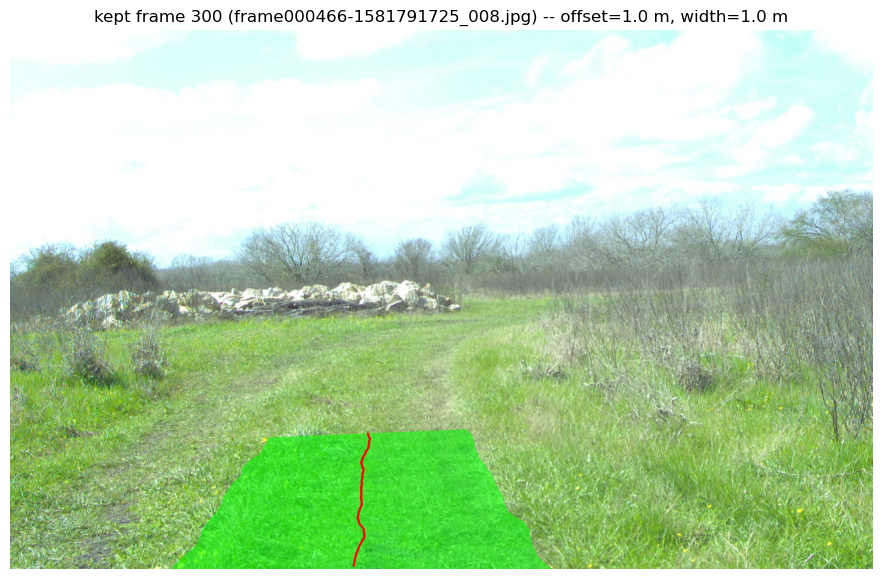

In [56]:
TEST_FRAME = 150   
test_frame_list = [i for i in range(TEST_FRAME, TEST_FRAME + 200,50)]

for idx in test_frame_list:
    idx = min(idx, len(imgs) - 1)
    mask, centers = path_mask(idx)
    over = make_overlay(idx, mask, centers)
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"kept frame {idx} ({imgs[idx].name}) -- offset={GROUND_OFFSET_M} m, width={ROBOT_WIDTH_M} m")
    plt.show()

## 8. Full run over every kept image → `pixels.json` + overlays

In [57]:
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

pixels = {}
n_pts = []
for i in tqdm(range(len(imgs))):
    mask, centers = path_mask(i)
    ys, xs = np.nonzero(mask[::PIXEL_STRIDE, ::PIXEL_STRIDE])
    pts = (np.stack([xs, ys], axis=1) * PIXEL_STRIDE)
    pixels[imgs[i].name] = pts.tolist()
    n_pts.append(len(pts))
    if OVERLAY_EVERY and i % OVERLAY_EVERY == 0:
        cv2.imwrite(str(OVERLAY_DIR / imgs[i].name), make_overlay(i, mask, centers))

n_pts = np.array(n_pts)
print(f"frames: {len(n_pts)}, empty-path frames: {(n_pts == 0).sum()} (expect a few at sequence end / sharp turns)")
print(f"path pixels per frame  p10/p50/p90: {np.percentile(n_pts, [10, 50, 90]).astype(int)}")

100%|██████████| 1743/1743 [00:08<00:00, 209.61it/s]

frames: 1743, empty-path frames: 51 (expect a few at sequence end / sharp turns)
path pixels per frame  p10/p50/p90: [1578 2570 3797]


In [58]:
with open(OUT_DIR / "pixels.json", "w") as f:
    json.dump(pixels, f)

meta = {
    "sequence": SEQ,
    "image_size": [IMG_W, IMG_H],
    "pixel_coords": "full-resolution (u, v); rescale by 700/W, 700/H for STEPP's 700x700 input",
    "future_steps": FUTURE_STEPS,
    "min_move_m": MIN_MOVE_M,
    "ground_offset_m": GROUND_OFFSET_M,
    "robot_width_m": ROBOT_WIDTH_M,
    "pixel_stride": PIXEL_STRIDE,
    "extrinsic_direction": EXTRINSIC_CHOICE,
    "n_frames_kept": len(imgs),
    "n_frames_total": len(img_paths),
    "intrinsics_fx_fy_cx_cy": [fx, fy, cx, cy],
    "distortion": "none available in camera_info.txt (D=0)",
}
with open(OUT_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("wrote", OUT_DIR / "pixels.json", f"({(OUT_DIR / 'pixels.json').stat().st_size / 1e6:.1f} MB)")
print("wrote", OUT_DIR / "meta.json")
print("overlays in", OVERLAY_DIR)

wrote s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00004\pixels.json (59.4 MB)
wrote s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00004\meta.json
overlays in s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00004\overlays


## 9. Spot-check a few results

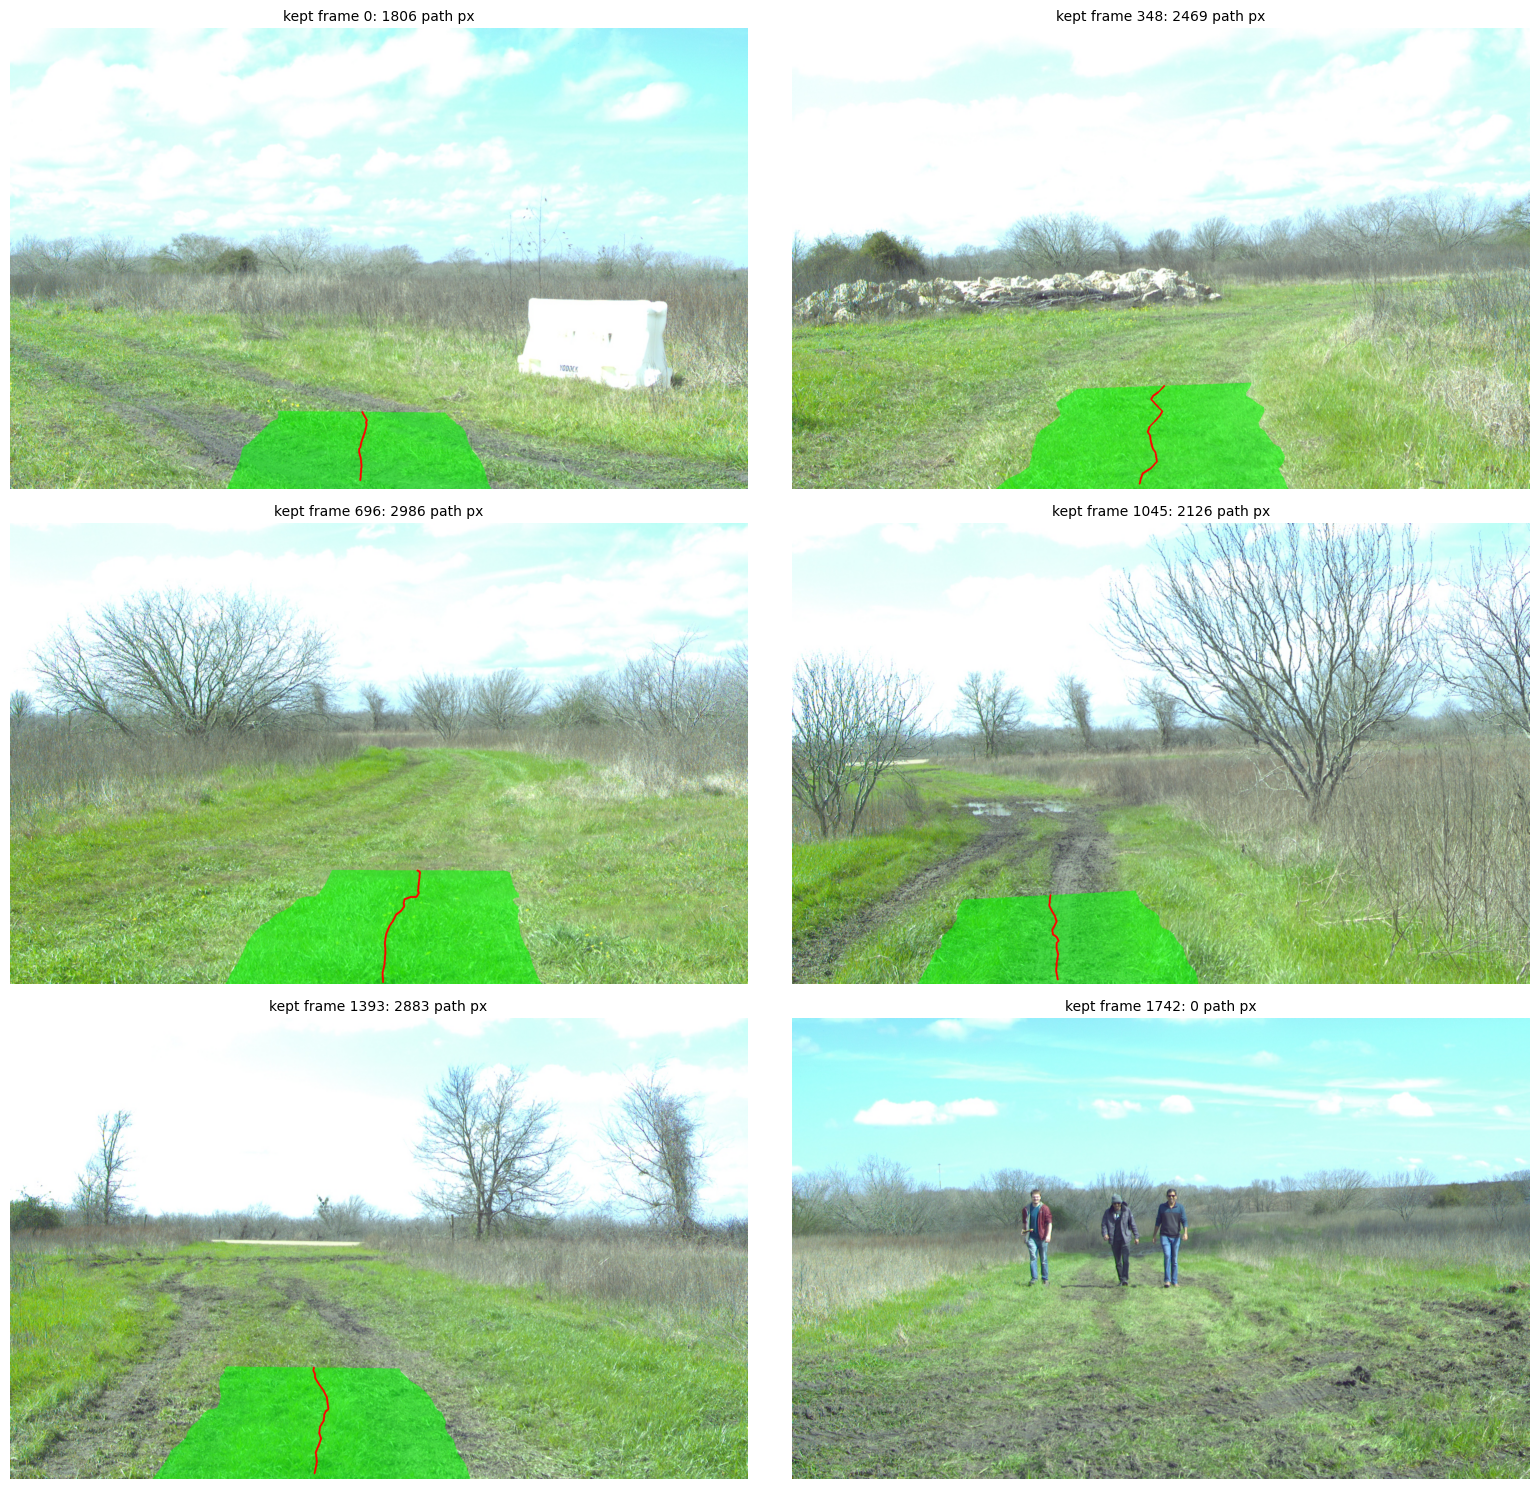

In [59]:
samples = np.linspace(0, len(imgs) - 1, 6).astype(int)
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for ax, idx in zip(axes.ravel(), samples):
    mask, centers = path_mask(idx)
    ax.imshow(cv2.cvtColor(make_overlay(idx, mask, centers), cv2.COLOR_BGR2RGB))
    ax.set_title(f"kept frame {idx}: {len(pixels[imgs[idx].name])} path px", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Red-line-only overlays + centerline JSON

Same projected future path as above, but drawn as **just the red centerline** (no green
ribbon). For the current `SEQ` this writes:
- `outputs/<SEQ>/line_pixels.json` — image name → list of `[u, v]` centerline points
  (full-res, in-image only); one polyline per image, one vertex per projected future pose.
- `outputs/<SEQ>/overlays_line/` — the line-only overlay images (every `OVERLAY_EVERY` frame).

Run it once per sequence (set `SEQ` in the CONFIG cell and re-run top to bottom), just like
the green-ribbon outputs.

In [60]:
LINE_OVERLAY_DIR = OUT_DIR / "overlays_line"
LINE_OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

def make_line_overlay(idx, centers):
    """RGB image with ONLY the projected future centerline drawn (red), no green ribbon."""
    img = cv2.imread(str(imgs[idx]))
    assert img is not None, f"cv2.imread failed: {imgs[idx]}"
    over = img.copy()
    inb = centers[np.all((centers >= 0) & (centers < [IMG_W, IMG_H]), axis=1)].astype(np.int32)
    if len(inb) >= 2:
        cv2.polylines(over, [inb], False, (0, 0, 255), 4)
    return over

line_pixels = {}
n_line = []
for i in tqdm(range(len(imgs))):
    _, centers = path_mask(i)                       # reuse the same projection; ignore the ribbon mask
    inb = centers[np.all((centers >= 0) & (centers < [IMG_W, IMG_H]), axis=1)]
    line_pixels[imgs[i].name] = inb.astype(int).tolist()
    n_line.append(len(inb))
    if OVERLAY_EVERY and i % OVERLAY_EVERY == 0:
        cv2.imwrite(str(LINE_OVERLAY_DIR / imgs[i].name), make_line_overlay(i, centers))

with open(OUT_DIR / "line_pixels.json", "w") as f:
    json.dump(line_pixels, f)

n_line = np.array(n_line)
print(f"frames: {len(n_line)}, frames with no in-image centerline: {(n_line == 0).sum()}")
print(f"centerline points per frame  p10/p50/p90: {np.percentile(n_line, [10, 50, 90]).astype(int)}")
print("wrote", OUT_DIR / "line_pixels.json", f"({(OUT_DIR / 'line_pixels.json').stat().st_size / 1e3:.0f} KB)")
print("line overlays in", LINE_OVERLAY_DIR)

100%|██████████| 1743/1743 [00:03<00:00, 466.80it/s]

frames: 1743, frames with no in-image centerline: 65
centerline points per frame  p10/p50/p90: [16 21 26]
wrote s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00004\line_pixels.json (518 KB)
line overlays in s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00004\overlays_line
